# Complexity-05 — Compter est plus dur que vérifier : #P et la permanente

**Navigation** : [<< Complexity-04b — Secrétaire matroïdal et k-server](Complexity-04b-OnlineConjectures-Secretary-KServer.ipynb) | [Index de la série](README.md) | [Complexity-05b — La permanente, frontière quantique >>](Complexity-05b-AaronsonArkhipov-PermanenteBosonSampling.ipynb)

> **Public : Licence.** La formule de Ryser, le boson sampling et la frontière quantique sont
> conservés pour l'approfondissement [05b](Complexity-05b-AaronsonArkhipov-PermanenteBosonSampling.ipynb) ;
> ce notebook s'arrête à la frontière #P.

## Ce que ce notebook suppose

- [02 — Vérifier ou trouver](Complexity-02-P-NP-Reduction.ipynb) : le **certificat** d'une
  instance, ce que signifie **vérifier** en temps polynomial, les classes **P** et **NP** ;
- lire un programme Python simple (boucles, fonctions, tableaux).

## Ce que vous saurez faire à la fin

1. définir la classe **#P** — **compter** les témoins d'une instance, et non plus seulement
   décider s'il en existe ;
2. écrire le **déterminant** et la **permanente** : la même somme de $n!$ produits, à un
   signe près ;
3. **mesurer** sur un banc réel l'écart entre un calcul polynomial et un calcul factoriel ;
4. énoncer le théorème de Valiant (**cité**) : la permanente est #P-difficile, même en 0/1 ;
5. relier un comptage naturel — les **couplages parfaits** d'un graphe biparti — à une
   permanente.

**Durée estimée** : 45 minutes.

In [1]:
import time
from itertools import permutations, product
from math import factorial, prod

import matplotlib.pyplot as plt
import numpy as np

print("numpy", np.__version__)

numpy 2.4.4


## 1. De vérifier à compter : la classe #P

Le notebook 02 séparait deux gestes : **trouver** une solution (aucun algorithme polynomial
connu sur les problèmes NP-complets) et **vérifier** un certificat proposé (facile,
polynomial). Un certificat que le vérificateur accepte s'appelle ici un **témoin**. Décider
s'il existe un témoin, c'est un problème de **NP**. Mais le certificat soulève une question
que NP ne pose même pas : **combien** y en a-t-il ?

Compter les témoins définit une nouvelle classe de fonctions :

> **#P** (lire *sharp-P*) : les fonctions qui à une instance $x$ associent le **nombre de
> témoins** de $x$.

Le comptage est au moins aussi difficile que la décision — un compte nul répond *non*, un
compte strictement positif répond *oui* — mais il est plus fin : il distingue des instances
que la décision confond. Déroulons un exemple complet, à la main, avant toute généralité :
l'expression à trois variables

$$\varphi(a, b, c) \;=\; (a \vee b) \wedge (\neg a \vee c)$$

Un certificat est un triplet de booléens ; un témoin, un triplet accepté par les deux
clauses. Il n'y en a que huit : énumérons-les tous.

In [2]:
# L'expression a deux clauses : verifier un certificat = lire chaque clause, c'est tout.
def phi(a, b, c):
    """(a ou b) et (non a ou c) -- le geste du notebook 02 : verifier est facile."""
    clause1 = 1 if (a or b) else 0
    clause2 = 1 if (not a or c) else 0
    return clause1, clause2


print(f"{'a':>2} {'b':>2} {'c':>2} | {'(a ou b)':>8} | {'(non a ou c)':>11} | temoin")
print("-" * 48)
nb_temoins = 0
for a, b, c in product((0, 1), repeat=3):
    c1, c2 = phi(a, b, c)
    temoin = c1 * c2          # accepte par les deux clauses : un produit, comme un et logique
    nb_temoins += temoin
    print(f"{a:>2} {b:>2} {c:>2} | {c1:>8} | {c2:>11} | {temoin:>6}")
print()
print(f"decision (NP) : existe-t-il un temoin ? -> {'OUI' if nb_temoins > 0 else 'NON'}")
print(f"comptage (#P)  : combien de temoins ?    -> {nb_temoins} sur 8 certificats")
assert nb_temoins == 4

 a  b  c | (a ou b) | (non a ou c) | temoin
------------------------------------------------
 0  0  0 |        0 |           1 |      0
 0  0  1 |        0 |           1 |      0
 0  1  0 |        1 |           1 |      1
 0  1  1 |        1 |           1 |      1
 1  0  0 |        1 |           0 |      0
 1  0  1 |        1 |           1 |      1
 1  1  0 |        1 |           0 |      0
 1  1  1 |        1 |           1 |      1

decision (NP) : existe-t-il un temoin ? -> OUI
comptage (#P)  : combien de temoins ?    -> 4 sur 8 certificats


**Lecture du résultat.** Quatre témoins sur huit certificats — et le tableau qui les exhibe
répond aux deux questions d'un coup : l'instance est satisfiable (au moins un témoin), et son
**compte** de satisfaisabilité vaut quatre. Mais l'énumération a payé $2^n$ lectures : le mur
exponentiel du notebook 02. La vraie question de #P est là : peut-on obtenir le **nombre**
sans tout énumérer ? Cette question vit sur un objet inattendu — une simple somme de produits
de matrice.

## 2. Le déterminant : des signes qui arrangent

Le déterminant d'une matrice $n \times n$ est, lui aussi, défini comme une somme sur les
permutations $\sigma$ de $\{0, \dots, n-1\}$ :

$$\det A \;=\; \sum_{\sigma} \mathrm{signe}(\sigma) \prod_{i=0}^{n-1} A[i,\sigma(i)]$$

Chaque permutation apporte son produit des $n$ entrées, multiplié par son **signe** ($+1$ ou
$-1$ selon la parité des échanges qui la composent). En $2 \times 2$, les deux permutations
redonnent le produit « en croix » connu :

$$\det\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc$$

La définition parcourt $n!$ termes — et pourtant le déterminant se calcule en
**polynomial** : l'élimination de Gauss factorise la matrice en triangles en environ
$\tfrac{2}{3}n^3$ opérations, et c'est elle que numpy exécute. Vérifions que le polynomial
se **voit** sur la machine : les tailles doublent, un cube promet un facteur $2^3 = 8$ —
voyons ce que la machine rend. (Le banc chronomètre `slogdet`, le **log**-déterminant :
la forme stable du même calcul de Gauss — le déterminant lui-même déborderait des flottants
à ces tailles.)

In [3]:
rng = np.random.default_rng(5)

print("log-determinant par np.linalg.slogdet : la meme elimination de Gauss, chronometree")
print("au minimum de 10 essais (machine partagee) ; le temps doit suivre un polynome en n")
print(f"{'n':>6} | {'temps (s)':>9} | {'x au doublement':>15} | {'temps / n^3':>12}")
print("-" * 52)

np.linalg.slogdet(rng.random((100, 100)))   # echauffement : alloue les threads une fois pour toutes

temps_prec = None
for n in (100, 200, 400, 800):
    A = rng.random((n, n))
    essais = []
    for _ in range(10):
        t0 = time.perf_counter()
        np.linalg.slogdet(A)
        essais.append(time.perf_counter() - t0)
    duree = min(essais)
    facteur = f"{duree / temps_prec:.1f}" if temps_prec is not None else "-"
    print(f"{n:>6} | {duree:>9.5f} | {facteur:>15} | {duree / n**3:>12.2e}")
    temps_prec = duree

print()
print("un facteur borne a chaque doublement : la signature d'un polynome en n,")
print("a opposer au facteur n qui grandit a chaque taille de la permanente")

log-determinant par np.linalg.slogdet : la meme elimination de Gauss, chronometree
au minimum de 10 essais (machine partagee) ; le temps doit suivre un polynome en n
     n | temps (s) | x au doublement |  temps / n^3
----------------------------------------------------
   100 |   0.00004 |               - |     4.23e-11
   200 |   0.00094 |            22.2 |     1.17e-10


   400 |   0.01134 |            12.1 |     1.77e-10

   800 |   0.15975 |            14.1 |     3.12e-10

un facteur borne a chaque doublement : la signature d'un polynome en n,
a opposer au facteur n qui grandit a chaque taille de la permanente


**Lecture du résultat.** À chaque doublement de $n$, le temps du log-déterminant est
multiplié par un facteur **borné** — supérieur au $2^3$ promis par la seule arithmétique,
car les accès mémoire ajoutent leur pente, mais qui ne **grandit pas** avec $n$ : c'est la
signature d'un polynôme. La définition, elle, compterait $800!$ termes — un nombre à près de
deux mille chiffres. La leçon tient dans ce contraste : **ce sont les signes qui rendent
Gauss possible**, en provoquant les annulations dont l'élimination exploite la cascade.

## 3. La permanente : la même somme, sans les signes

Retirons les signes, gardons tout le reste. La **permanente** additionne les mêmes $n!$
produits, tous comptés positivement :

$$\mathrm{perm}(A) \;=\; \sum_{\sigma} \prod_{i=0}^{n-1} A[i,\sigma(i)]$$

En $2 \times 2$ : $\mathrm{perm}\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad + bc$ —
contre $ad - bc$ pour le déterminant. Déroulons une $3 \times 3$ à la main, permutation par
permutation :

$$A = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{pmatrix}$$

| $\sigma$ | produit | valeur |
|---|---|---|
| $(0,1,2)$ | $1 \cdot 5 \cdot 9$ | $45$ |
| $(0,2,1)$ | $1 \cdot 6 \cdot 8$ | $48$ |
| $(1,0,2)$ | $2 \cdot 4 \cdot 9$ | $72$ |
| $(1,2,0)$ | $2 \cdot 6 \cdot 7$ | $84$ |
| $(2,0,1)$ | $3 \cdot 4 \cdot 8$ | $96$ |
| $(2,1,0)$ | $3 \cdot 5 \cdot 7$ | $105$ |

La somme vaut $450$. La même matrice a un déterminant **nul** — les signes s'y annihilent
totalement, la permanente additionne tout. Le banc suivant exécute la définition **telle
quelle**, un terme par permutation : copie pédagogique déclarée, c'est précisément le point
du cours (l'approfondissement 05b réutilise cette définition, puis la contourne par la
formule de Ryser — hors périmètre ici).

In [4]:
def permanente(A):
    """Permanent de A par la definition : la somme des n! produits, un par permutation.

    Copie pedagogique declaree : le point du cours est d'executer la definition
    telle quelle -- ce banc ne cherche aucune astuce.
    """
    n = len(A)
    total = 0
    for p in permutations(range(n)):
        total += prod(A[i][p[i]] for i in range(n))
    return total


# Comptes canoniques : la definition contre les formules fermees.
IDENTITE_3 = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
M_22 = [[1, 2], [3, 4]]
M_33 = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

print("comptes canoniques :")
print(f"  identite 3x3        : {permanente(IDENTITE_3)}   (formule attendue : 1)")
print(f"  [[1,2],[3,4]]       : {permanente(M_22)}  (a la main : 1*4 + 2*3 = 10)")
print(f"  3x3 1..9            : {permanente(M_33)} (le tableau ci-dessus : 450)")
det_33 = int(round(float(np.linalg.det(np.array(M_33)))))
print(f"  det de la meme 3x3  : {det_33}    (avec les signes, tout s'annule)")
print()
print("matrices tout-un : la permanente vaut n! a chaque taille")
for n in range(1, 6):
    tout_un = [[1] * n for _ in range(n)]
    valeur = permanente(tout_un)
    assert valeur == factorial(n)
    print(f"  n = {n} : perm = {valeur:>3} = {n}!")

comptes canoniques :
  identite 3x3        : 1   (formule attendue : 1)
  [[1,2],[3,4]]       : 10  (a la main : 1*4 + 2*3 = 10)
  3x3 1..9            : 450 (le tableau ci-dessus : 450)
  det de la meme 3x3  : 0    (avec les signes, tout s'annule)

matrices tout-un : la permanente vaut n! a chaque taille
  n = 1 : perm =   1 = 1!
  n = 2 : perm =   2 = 2!
  n = 3 : perm =   6 = 3!
  n = 4 : perm =  24 = 4!
  n = 5 : perm = 120 = 5!


**Lecture du résultat.** Les comptes canoniques tombent les uns après les autres : l'identité
ne laisse qu'un seul terme non nul (celui de la permutation identité), les matrices tout-un
valent $n!$ (autant de produits que de permutations, tous égaux à 1), et le contraste final
est net — permanente $450$, déterminant $0$ sur la même matrice. La définition est correcte ;
reste à en payer le prix, et à le comparer à celui de Gauss.

## 4. L'écart mesuré : polynomial contre factoriel

Mêmes tailles, mêmes matrices, deux algorithmes : d'un côté `np.linalg.det` (élimination de
Gauss, environ $\tfrac{2}{3}n^3$ opérations), de l'autre `permanente` (la définition, $n!$
termes). Les tailles vont de $n = 2$ à $n = 10$ — au-delà, la définition sortirait du budget
d'un notebook, et l'extrapolation prendra le relais. Chronomètre au `perf_counter`, puis
échelle logarithmique : c'est elle qui rend une factorielle lisible.

  n |       n! | permanente (s) | x au pas prec. | determinant (s) | perm / det
--------------------------------------------------------------------------------
  2 |        2 |       0.000007 |             - |       0.0000416 |         0
  3 |        6 |       0.000008 |           1.1 |       0.0000131 |         1
  4 |       24 |       0.000012 |           1.4 |       0.0000061 |         2
  5 |      120 |       0.000053 |           4.4 |       0.0000046 |        11
  6 |      720 |       0.000347 |           6.6 |       0.0000050 |        69
  7 |     5040 |       0.003190 |           9.2 |       0.0000291 |       110
  8 |    40320 |       0.034557 |          10.8 |       0.0000399 |       866
  9 |   362880 |       0.228124 |           6.6 |       0.0000547 |      4170
 10 |  3628800 |       2.720281 |          11.9 |       0.0000396 |     68694

extrapole sur cette machine, definition a n = 11 (4.0e+07 termes) : 29.923 s
extrapole sur cette machine, definition a n = 12 (4.8e+08 t

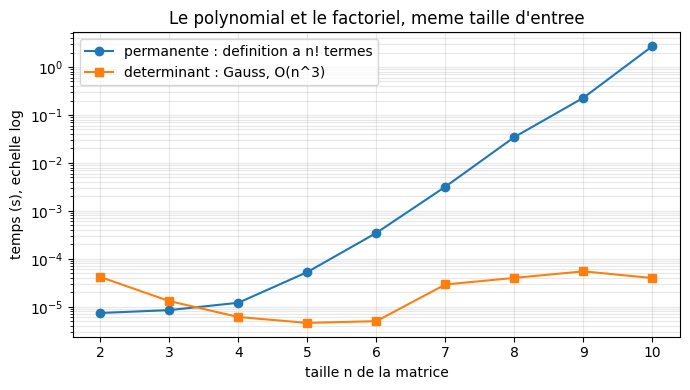

In [5]:
rng = np.random.default_rng(2026)

tailles = list(range(2, 11))
chrono_perm, chrono_det = [], []
for n in tailles:
    A = rng.integers(0, 10, size=(n, n)).tolist()   # entiers : la definition tourne telle quelle
    t0 = time.perf_counter()
    permanente(A)
    chrono_perm.append(time.perf_counter() - t0)

    A_numpy = np.array(A, dtype=float)
    t0 = time.perf_counter()
    np.linalg.det(A_numpy)
    chrono_det.append(time.perf_counter() - t0)

print(f"{'n':>3} | {'n!':>8} | {'permanente (s)':>14} | {'x au pas prec.':>13} | "
      f"{'determinant (s)':>15} | {'perm / det':>9}")
print("-" * 80)
for i, n in enumerate(tailles):
    facteur = f"{chrono_perm[i] / chrono_perm[i - 1]:.1f}" if i > 0 else "-"
    print(f"{n:>3} | {factorial(n):>8} | {chrono_perm[i]:>14.6f} | {facteur:>13} | "
          f"{chrono_det[i]:>15.7f} | {chrono_perm[i] / chrono_det[i]:>9.0f}")


def lisible(secondes):
    """Formate une duree en unites humaines, comme dans le notebook 02."""
    for unite, taille in (("annees", 31_557_600), ("jours", 86_400), ("heures", 3_600), ("min", 60)):
        if secondes >= taille:
            return f"{secondes / taille:,.1f} {unite}".replace(",", " ")
    return f"{secondes:.3f} s"


cout_terme = chrono_perm[-1] / factorial(10)   # temps moyen par terme, mesure a n = 10
print()
for n in (11, 12, 15, 20):
    print(f"extrapole sur cette machine, definition a n = {n} ({factorial(n):.1e} termes) : "
          f"{lisible(cout_terme * factorial(n))}")

plt.figure(figsize=(7, 4))
plt.semilogy(tailles, chrono_perm, "o-", label="permanente : definition a n! termes")
plt.semilogy(tailles, chrono_det, "s-", label="determinant : Gauss, O(n^3)")
plt.xlabel("taille n de la matrice")
plt.ylabel("temps (s), echelle log")
plt.title("Le polynomial et le factoriel, meme taille d'entree")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Lecture du résultat.** La colonne « x au pas précédent » raconte tout : le facteur de la
permanente **grandit avec $n$** — il approche dix entre $n = 9$ et $n = 10$, exactement le
facteur que la taille ajoute au compte $n!$. Le déterminant, lui, reste sur un plancher : à
ces petites tailles, son coût est dominé par l'appel de la bibliothèque, et c'est bien le
message — le polynomial, c'est presque rien ; le factoriel, c'est le mur. L'extrapolation,
bâtie sur le temps par terme **mesuré** à $n = 10$, en donne les ordres de grandeur : encore
traitable à $n = 12$, hors de toute patience humaine vers $n = 15$. Sur l'échelle log, la
factorielle apparaît comme une droite qui grimpe — légèrement accélérée. Et comme dans 02, le
matériel ne sauve rien : une machine mille fois plus rapide ne recule la frontière que de
deux à trois tailles.

## 5. Valiant 1979 : compter est #P-difficile (cité)

Un banc ne mesure qu'un programme — il ne dit rien des programmes qu'on n'a pas écrits. La
question sérieuse : un « Gauss de la permanente » existe-t-il ? Une astuce qui, exploitant la
structure de la somme, la ferait tomber à un polynomial ? Le théorème de Valiant ferme cette
porte de la façon la plus spectaculaire possible :

> **Théorème (Valiant, 1979 — cité, non démontré ici).** Calculer la permanente d'une matrice
> à coefficients $0$ et $1$ est **#P-difficile** : tout problème de #P — tout comptage de
> témoins — se réduit à ce calcul en temps polynomial.

La preuve (une réduction depuis le comptage des satisfaisations d'une formule 3-SAT) est un
chef-d'œuvre technique, hors de portée d'un notebook de licence ; l'énoncé seul suffit pour
la leçon :

1. **un algorithme polynomial pour la permanente 0/1 résoudrait tout comptage** : chaque
   problème de #P s'y réduirait, et la classe entière des comptages s'effondrerait sur les
   calculs polynomiaux (P = #P) ;
2. **les coefficients ne sont pas le problème** : des $0$ et des $1$ suffisent à la
   difficulté ;
3. le retournement est complet pour les graphes : décider s'il existe un couplage parfait
   dans un graphe biparti est **facile** (polynomial) — mais les compter, c'est
   carrément #P-difficile, et la section suivante montre pourquoi : ce comptage est une
   permanente.

La somme la plus simple du monde — des produits, tous comptés positivement — est donc
conjecturée hors de portée de tout algorithme polynomial.

## 6. Compter des couplages parfaits : c'est une permanente

Un graphe **biparti** : des sommets à gauche $u_0, \dots, u_3$, des sommets à droite
$d_0, \dots, d_3$, des arêtes entre les deux côtés seulement. Un **couplage parfait** apparie
chaque sommet de gauche à un voisin de droite, tous distincts — quatre arêtes, aucun sommet
utilisé deux fois. Les compter, c'est le comptage le plus naturel du monde : affecter des
tâches à des machines, des étudiants à des projets.

Voici le nôtre, dessiné comme un tableau à deux dimensions — une ligne par $u_i$, une colonne
par $d_j$, un point par arête :

```
        d0    d1    d2    d3
u0      ●     ●     ·     ·
u1      ●     ●     ●     ·
u2      ·     ●     ●     ●
u3      ·     ·     ●     ●
```

Ce tableau **est** la matrice d'adjacence $M$ du graphe (1 si l'arête existe, 0 sinon). Et
alors :

$$\#\{\text{couplages parfaits}\} \;=\; \mathrm{perm}(M)$$

La raison tient en deux lignes : un couplage parfait choisit pour chaque $u_i$ une
destination, toutes distinctes — autrement dit une permutation $\sigma$ ; et le produit des
$M[i,\sigma(i)]$ vaut $1$ exactement quand toutes les arêtes choisies existent, $0$ sinon.
Chaque couplage parfait contribue $1$ à la somme, chaque autre permutation $0$. Le banc
suivant le vérifie avec **deux machines indépendantes** : la permanente d'un côté, et de
l'autre une énumération brute qui construit chaque candidat sommet par sommet — chaque $u_i$
essaie chacun de ses voisins — et ne garde que les choix tous distincts.

In [6]:
# Le graphe ci-dessus, en machine : les aretes (i, j) = u_i vers d_j.
ARETES = {(0, 0), (0, 1),
          (1, 0), (1, 1), (1, 2),
          (2, 1), (2, 2), (2, 3),
          (3, 2), (3, 3)}

M = [[1 if (i, j) in ARETES else 0 for j in range(4)] for i in range(4)]
print("matrice d'adjacence :")
for ligne in M:
    print("   ", ligne)
print()

# Machine 1 : la permanente de la matrice d'adjacence.
print("permanente(M) =", permanente(M))
print()

# Machine 2 : enumeration brute, independante -- chaque u_i choisit un voisin,
# on ne garde que les choix ou toutes les destinations sont distinctes.
voisins = [[j for j in range(4) if (i, j) in ARETES] for i in range(4)]
couplages = [choix for choix in product(*voisins) if len(set(choix)) == 4]

print(f"enumeration brute : {len(couplages)} couplages parfaits")
for choix in couplages:
    print("    ", "   ".join(f"u{i}->d{choix[i]}" for i in range(4)))
assert permanente(M) == len(couplages)
print()
print("les deux machines s'accordent : le nombre de couplages parfaits EST la permanente")

matrice d'adjacence :
    [1, 1, 0, 0]
    [1, 1, 1, 0]
    [0, 1, 1, 1]
    [0, 0, 1, 1]

permanente(M) = 5

enumeration brute : 5 couplages parfaits
     u0->d0   u1->d1   u2->d2   u3->d3
     u0->d0   u1->d1   u2->d3   u3->d2
     u0->d0   u1->d2   u2->d1   u3->d3
     u0->d1   u1->d0   u2->d2   u3->d3
     u0->d1   u1->d0   u2->d3   u3->d2

les deux machines s'accordent : le nombre de couplages parfaits EST la permanente


**Lecture du résultat.** Les deux machines indépendantes rendent le même compte : la
permanente de la matrice d'adjacence vaut exactement le nombre de couplages listés un par un.
Le pont est franchi — un comptage naturel est littéralement une permanente de matrice 0/1,
et par le théorème de Valiant, compter les couplages parfaits d'un graphe biparti est
une tâche #P-difficile dans le cas général : décider s'il en existe un est polynomial,
les compter ne l'est probablement pas.

Et l'histoire a continué : Aaronson et Arkhipov (2011) ont montré que la distribution de
sortie d'un réseau optique linéaire — des photons dans un interféromètre — dépend de
permanentes de matrices complexes, faisant de la fonction la plus dure du comptage classique
le candidat le plus sérieux d'un avantage quantique démontrable. Cette frontière est celle de
l'approfondissement [05b — La permanente, frontière quantique](Complexity-05b-AaronsonArkhipov-PermanenteBosonSampling.ipynb).

## Exercices

Chaque cellule s'exécute sans erreur telle qu'elle est livrée : remplacez les lignes
`# TODO etudiant` par votre solution.

### Exercice 1 — Compter à la main

Le banc de la section 3 l'a écrite en une boucle ; écrivez la vôtre, étape par étape, sans
la recopier — c'est en l'écrivant que la définition à $n!$ termes devient concrète.

- **Etape 1 :** parcourir toutes les permutations `p` de `range(n)`, avec
  `itertools.permutations` (déjà importé) ;
- **Etape 2 :** pour chaque `p`, calculer le produit des $A[i][p[i]]$ sur les lignes $i$ ;
- **Etape 3 :** accumuler la somme des produits et la renvoyer.
- **Indice :** `math.prod` sur un générateur fait l'étape 2 en une seule expression.

La cellule valide trois comptes : l'identité $3 \times 3$ (un seul terme non nul), la matrice
tout-un $3 \times 3$ ($3!$ produits égaux à 1), et la matrice de l'énoncé, de permanente
connue.

In [7]:
# Exercice 1 : a completer
MATRICE_EXO = [[1, 1, 1],
               [1, 1, 0],
               [1, 0, 1]]      # sa permanente vaut 3 (valeur fournie pour l'auto-verification)


def perm_def(A):
    """Permanent de A par la definition : la somme des n! produits, un par permutation."""
    n = len(A)
    total = 0
    # Etape 1 : parcourir toutes les permutations p de range(n)
    # Etape 2 : pour chaque p, calculer le produit des A[i][p[i]] sur les i
    # Etape 3 : accumuler dans total, puis renvoyer total
    # Indice : une boucle for, math.prod sur un generateur, et c'est tout
    # TODO etudiant
    return None


tests_exo1 = [("identite 3x3", [[1, 0, 0], [0, 1, 0], [0, 0, 1]], 1),
              ("tout-un 3x3", [[1, 1, 1], [1, 1, 1], [1, 1, 1]], 6),
              ("matrice de l'enonce", MATRICE_EXO, 3)]

if perm_def(tests_exo1[0][1]) is None:
    print("Exercice a completer : perm_def renvoie encore None")
else:
    for nom, A, attendu in tests_exo1:
        valeur = perm_def(A)
        verdict = "OK" if valeur == attendu else "ECHEC"
        print(f"{nom:>22} : perm_def = {valeur} (attendu {attendu}) {verdict}")

Exercice a completer : perm_def renvoie encore None


### Exercice 2 — L'échelle mesurée

La section 4 a chronométré la permanente du banc jusqu'à $n = 10$. Faites la mesure
vous-même, avec votre `perm_def` de l'exercice 1 : pour chaque taille $n$ de 2 à 9, engendrer
une matrice d'entiers aléatoires, chronométrer `perm_def` au `time.perf_counter`, et remplir
la liste `mesures`.

- **Etape 1 :** la boucle de mesure sur $n = 2, 3, \dots, 9$ ;
- **Etape 2 :** reporter le temps de chaque taille dans `mesures`, dans l'ordre croissant
  des $n$ ;
- **Etape 3 :** la cellule trace ensuite le temps en échelle log contre $n$ et affiche les
  facteurs d'une taille à la suivante.
- **Indice :** sur l'échelle log, on attend une **droite** qui monte — chaque taille
  supplémentaire multiplie le temps par environ $n$.

In [8]:
# Exercice 2 : a completer
mesures = None  # TODO etudiant : liste des durees de perm_def pour n = 2, 3, ..., 9

if mesures is None:
    print("Exercice a completer : mesures de temps pour n = 2 a 9 (boucle + time.perf_counter)")
else:
    ns = list(range(2, 10))
    plt.figure(figsize=(7, 4))
    plt.semilogy(ns, mesures, "o-", label="perm_def : temps mesure")
    plt.xlabel("taille n de la matrice")
    plt.ylabel("temps (s), echelle log")
    plt.title("Exercice 2 : la definition a n! termes, en echelle log")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    facteurs = [mesures[i + 1] / mesures[i] for i in range(len(mesures) - 1)]
    print("facteurs d'un n au suivant :", ", ".join(f"{f:.1f}" for f in facteurs))
    print("un facteur proche de n : chaque taille ajoutee multiplie le travail par n")

Exercice a completer : mesures de temps pour n = 2 a 9 (boucle + time.perf_counter)


### Exercice 3 — Couplages parfaits

Le graphe biparti ci-dessous a trois sommets de chaque côté ; les arêtes sont les traits du
dessin :

```
         d0
        /  \
      u0    u2
      |      |
      d1    d2
        \  /
         u1
```

- **Etape 1 :** prédire, en lisant le dessin, combien de couplages parfaits possède ce
  graphe ;
- **Etape 2 :** écrire sa matrice d'adjacence $3 \times 3$ — une ligne par $u_i$, une colonne
  par $d_j$, un 1 si l'arête existe, un 0 sinon ;
- **Etape 3 :** la cellule vérifie avec la permanente du banc ; votre `perm_def` doit rendre
  la même valeur.
- **Indice :** chaque sommet a exactement deux voisins — dès que le partenaire de $u_0$ est
  choisi, suivez les choix qui s'imposent.

In [9]:
# Exercice 3 : a completer
matrice = None     # TODO etudiant : la matrice d'adjacence 3x3 du graphe ci-dessus
prediction = None  # TODO etudiant : votre pronostic, lu sur le dessin (un entier)

if matrice is None:
    print("Exercice a completer : ecrire la matrice d'adjacence du graphe de l'enonce")
else:
    compte = permanente(matrice)
    print(f"permanente de votre matrice : {compte} couplages parfaits")
    if prediction is None:
        print("pronostic a remplir aussi : prediction = votre nombre, lu sur le dessin")
    elif prediction == compte:
        print("pronostic exact : le dessin se lit, la permanente le confirme")
    else:
        print(f"pronostic {prediction} different du compte {compte} : relisez le dessin (ou la matrice)")

Exercice a completer : ecrire la matrice d'adjacence du graphe de l'enonce


## Conclusion

| Question | Le geste de ce notebook | Statut |
|---|---|---|
| Vérifier ou compter ? | #P : les témoins d'une expression, énumérés à la main | **mesuré** |
| Le déterminant | la définition à $n!$ termes tombe à $O(n^3)$ par Gauss | **mesuré** (facteur borné au doublement) |
| La permanente | la même somme sans les signes, $n!$ termes exécutés | **mesuré** (facteur qui croît vers $n$ entre $n=5$ et $n=10$ — overhead domine en deça) |
| Peut-on faire mieux ? | Valiant 1979 : #P-difficile, même en 0/1 | **cité** |
| Un comptage naturel | couplages parfaits = permanente, deux machines d'accord | **mesuré** |

Ce que ce notebook a établi :

1. **#P** compte les témoins là où **NP** demande seulement s'il en existe : une question
   plus fine, qui n'hérite d'aucun raccourci de la vérification.
2. Le **déterminant** et la **permanente** partagent la même somme de $n!$ produits ; les
   signes du premier autorisent les annulations de Gauss, leur absence maintient la seconde
   à l'échelle factorielle — l'écart a été **chronométré**, pas seulement affirmé.
3. Cette difficulté n'est pas une impression de banc : c'est un **théorème** (Valiant, cité)
   qui fait de la permanente le représentant le plus dur de toute la classe #P — et le pont
   vers les graphes est franchi : compter leurs couplages parfaits, c'est déjà une permanente.

La suite de l'histoire est quantique : la distribution de sortie d'un interféromètre linéaire
dépend de permanentes complexes, et c'est sur ce mur qu'Aaronson et Arkhipov ont fondé leur
proposition d'un avantage quantique démontrable — l'approfondissement 05b le fait tourner.

**Suite** : [Complexity-05b — La permanente, frontière quantique >>](Complexity-05b-AaronsonArkhipov-PermanenteBosonSampling.ipynb)

**Références**

- Valiant, L. G. (1979), *The Complexity of Computing the Permanent*, Theoretical Computer Science 8(2), 189–201.
- Aaronson, S. et Arkhipov, A. (2011), *The Computational Complexity of Linear Optics*, Proceedings of the 43rd ACM Symposium on Theory of Computing (STOC), 333–342.
- Minc, H. (1978), *Permanents*, Encyclopedia of Mathematics and its Applications 6, Addison-Wesley.